In [ ]:
import numpy as np
from scipy.special import gammaln
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
#Toy Problem

In [ ]:
#Functions and explanations

# ---------- Multivariate Student-t log density ----------
def log_mvt(x, nu, mu, Sigma):
    """
    Computes the log-density of a Multivariate Student-t distribution.
    This is used as the 'marginal likelihood' when the Gaussian parameters
    (mean and covariance) are integrated out.
    """
    x = np.asarray(x)
    mu = np.asarray(mu)
    d = x.shape[0]

    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        return -np.inf

    inv_Sigma = np.linalg.inv(Sigma)
    diff = x - mu
    mahal = diff @ inv_Sigma @ diff

    # Normalization constant in log space
    log_const = (
        gammaln((nu + d) / 2.0) - gammaln(nu / 2.0)
        - (d / 2.0) * np.log(nu * np.pi)
        - 0.5 * logdet
    )

    # The 'kernel' of the Student-t distribution
    log_kernel = -0.5 * (nu + d) * np.log(1.0 + mahal / nu)
    return log_const + log_kernel


# ============================================================
# Collapsed Gibbs for Pitman–Yor Gaussian mixture (NIW base)
# Integrates out (mu, Sigma) -> predictive is multivariate t
# ============================================================
def gibbs_pitmanyor_2d_collapsed(
    y,
    n_iter=1000,
    alpha=3.0,
    d=0.3,
    m0=None,
    kappa0=1.0,
    nu0=None,
    Lambda0=None,
    seed=1234,
):

    """
    ESTIMATING a Pitman-Yor Process (PYP) mixture.
    'Collapsed' means we integrate out the cluster parameters (mu, Sigma).
    Instead of sampling them, we use the predictive Student-t distribution.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    n, dim = y.shape

    #hyperparameters
    if m0 is None:
        m0 = y.mean(axis=0)
    m0 = np.asarray(m0, dtype=float)

    if nu0 is None:
        # Must satisfy nu0 > dim - 1 for Inv-Wishart;
        nu0 = dim + 2.0

    if Lambda0 is None:
        # Prior scale (roughly) -> larger means broader prior
        Lambda0 = np.eye(dim) * 0.2
    Lambda0 = np.asarray(Lambda0, dtype=float)

    if nu0 <= dim - 1:
        raise ValueError(f"nu0 must be > dim-1. Got nu0={nu0}, dim={dim}")

    # Helper: predictive t parameters from cluster sufficient stats -updates niw
    def pred_t_params(nj, sum_y, sum_yyT):
       """
        Uses Bayesian conjugacy to calculate the parameters of the
        predictive Student-t distribution based on current cluster members.
        """
        if nj == 0:
            kappa_n = kappa0
            nu_n = nu0
            m_n = m0
            Lambda_n = Lambda0
        else:
            ybar = sum_y / nj
            # Scatter S = sum (y - ybar)(y - ybar)^T
            S = sum_yyT - nj * np.outer(ybar, ybar)

            kappa_n = kappa0 + nj
            nu_n = nu0 + nj
            m_n = (kappa0 * m0 + nj * ybar) / kappa_n

            diff = (ybar - m0).reshape(-1, 1)
            Lambda_n = Lambda0 + S + (kappa0 * nj / kappa_n) * (diff @ diff.T)

        # Degrees of freedom and scale for the marginal Student-t
        nu_pred = nu_n - dim + 1.0
        if nu_pred <= 0:
            return None  # invalid

        Sigma_pred = (kappa_n + 1.0) / (kappa_n * nu_pred) * Lambda_n
        return nu_pred, m_n, Sigma_pred

    # Initial state: assign all points to a single cluster
    S = np.ones(n, dtype=int)
    clusters = {
        1: {
            "indices": list(range(n)),
            "n": n,
            "sum_y": y.sum(axis=0).copy(),
            "sum_yyT": (y.T @ y).copy(),  # sum of outer products
        }
    }

    S_trace = np.zeros((n_iter, n), dtype=int)
    k_trace = np.zeros(n_iter, dtype=int)
    # --- MAIN GIBBS SAMPLING LOOP ---
    for it in range(n_iter):
        for i in range(n):
            old_label = S[i]
            cl = clusters[old_label]

            # STEP 1: Remove observation i from its current cluster
            cl["indices"].remove(i)
            cl["n"] -= 1
            cl["sum_y"] -= y[i]
            cl["sum_yyT"] -= np.outer(y[i], y[i])

            if cl["n"] == 0:
                del clusters[old_label]
            else:
                clusters[old_label] = cl

            # STEP 2: Calculate probabilities for cluster reassignment
            cl_labels = sorted(clusters.keys())
            k = len(cl_labels)
            log_weights = np.full(k + 1, -np.inf)

            # Weight for existing clusters (Pitman-Yor seating rule)
            for idx, label in enumerate(cl_labels):
                cinfo = clusters[label]
                nj = cinfo["n"]

                prior_factor = nj - d
                if prior_factor <= 0:
                    # If discount d is too large for tiny clusters
                    continue

                params = pred_t_params(nj, cinfo["sum_y"], cinfo["sum_yyT"])
                if params is None:
                    continue
                nu_pred, mu_pred, Sigma_pred = params

                log_pred = log_mvt(y[i], nu=nu_pred, mu=mu_pred, Sigma=Sigma_pred)
                log_weights[idx] = np.log(prior_factor) + log_pred

            # Weight for starting a NEW cluster
            prior_new = alpha + d * k
            if prior_new <= 0:
                raise ValueError("alpha + d*k must be > 0. Check alpha, d, and k.")

            params0 = pred_t_params(0, np.zeros(dim), np.zeros((dim, dim)))
            nu0_pred, mu0_pred, Sigma0_pred = params0
            log_pred0 = log_mvt(y[i], nu=nu0_pred, mu=mu0_pred, Sigma=Sigma0_pred)
            log_weights[k] = np.log(prior_new) + log_pred0

           # STEP 3: Sample the new cluster label using Log-Sum-Exp trick
            maxlw = np.max(log_weights)
            w = np.exp(log_weights - maxlw)
            probs = w / w.sum()

            # STEP 4: Update cluster structures with the new assignment
            choice = rng.choice(k + 1, p=probs)
            if choice < k:
                new_label = cl_labels[choice]
            else:
                new_label = (max(clusters.keys()) + 1) if clusters else 1
                clusters[new_label] = {
                    "indices": [],
                    "n": 0,
                    "sum_y": np.zeros(dim),
                    "sum_yyT": np.zeros((dim, dim)),
                }

            # add i to chosen cluster
            S[i] = new_label
            clusters[new_label]["indices"].append(i)
            clusters[new_label]["n"] += 1
            clusters[new_label]["sum_y"] += y[i]
            clusters[new_label]["sum_yyT"] += np.outer(y[i], y[i])

        S_trace[it] = S
        k_trace[it] = len(clusters)

    return S_trace, k_trace

# ============================================================
# Collapsed Gibbs for Pitman–Yor PPMx (Gaussian likelihood on y)
# Partition prior is modulated by covariate similarity g(x_cluster)
# Uses NIW marginal likelihood for x
# ============================================================
def gibbs_ppmx_pitmanyor_2d_collapsed(
    y,              # (n, Dy)  -> "response" / physical variables (e.g., lat-lon)
    x,              # (n, Dx)  -> covariates / exogenous variables
    n_iter=1000,
    alpha=1.0,
    d=0.3,
    eta=1.0,        # strength of covariate influence; eta=0 reduces to standard PY on y
    # NIW hyperparams for y-likelihood
    m0_y=None,
    kappa0_y=1.0,
    nu0_y=None,
    Lambda0_y=None,
    # NIW hyperparams for x-similarity
    m0_x=None,
    kappa0_x=1.0,
    nu0_x=None,
    Lambda0_x=None,
    seed=1234,
):
    """
    PPMx version of collapsed Pitman–Yor Gaussian mixture.

    Likelihood model (collapsed):
      y_i | cluster j ~ multivariate Student-t (NIW integrated out)

    Partition prior (PPMx):
      multiplies Pitman–Yor cohesion by a covariate similarity term:
        g(x_cluster) = NIW marginal likelihood of x within the cluster
      so assignment uses ratios:
        g(x_j ∪ {x_i}) / g(x_j)

    Full conditional:
      P(c_i=j | rest) ∝ (n_{-i,j} - d) * p_y(y_i | y_{-i,j}) * [g_x(new)/g_x(old)]^eta
      P(c_i=new| rest) ∝ (alpha + d*k) * p_y(y_i | prior) * [g_x({x_i})]^eta

    ESTIMATING a Product Partition Model with Covariates (PPMx).
    Similarity in covariate space (x) influences the clustering of response (y).

    """
    rng = np.random.default_rng(seed)

    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    n, Dy = y.shape
    n2, Dx = x.shape
    if n2 != n:
        raise ValueError("y and x must have same number of rows.")

    # ---------- Defaults for y (likelihood) ----------
    if m0_y is None:
        m0_y = y.mean(axis=0)
    m0_y = np.asarray(m0_y, dtype=float)
    if nu0_y is None:
        nu0_y = Dy + 2.0
    if Lambda0_y is None:
        Lambda0_y = np.eye(Dy) * 5.0
    Lambda0_y = np.asarray(Lambda0_y, dtype=float)
    if nu0_y <= Dy - 1:
        raise ValueError(f"nu0_y must be > Dy-1. Got nu0_y={nu0_y}, Dy={Dy}")

    # ---------- Defaults for x (covariates similarity) ----------
    if m0_x is None:
        m0_x = x.mean(axis=0)
    m0_x = np.asarray(m0_x, dtype=float)
    if nu0_x is None:
        nu0_x = Dx + 2.0
    if Lambda0_x is None:
        Lambda0_x = np.eye(Dx)
    Lambda0_x = np.asarray(Lambda0_x, dtype=float)
    if nu0_x <= Dx - 1:
        raise ValueError(f"nu0_x must be > Dx-1. Got nu0_x={nu0_x}, Dx={Dx}")

    if not (alpha > 0):
        raise ValueError("alpha must be > 0.")
    if not (0 <= d < 1):
        raise ValueError("discount d must satisfy 0 <= d < 1.")
    if eta < 0:
        raise ValueError("eta must be >= 0.")

    # ---------- helper: predictive t params from NIW stats ----------
    def pred_t_params(nj, sum_v, sum_vvT, m0, kappa0, nu0, Lambda0, D):
        if nj == 0:
            kappa_n = kappa0
            nu_n = nu0
            m_n = m0
            Lambda_n = Lambda0
        else:
            vbar = sum_v / nj
            S = sum_vvT - nj * np.outer(vbar, vbar)
            kappa_n = kappa0 + nj
            nu_n = nu0 + nj
            m_n = (kappa0 * m0 + nj * vbar) / kappa_n
            diff = (vbar - m0).reshape(-1, 1)
            Lambda_n = Lambda0 + S + (kappa0 * nj / kappa_n) * (diff @ diff.T)

        nu_pred = nu_n - D + 1.0
        if nu_pred <= 0:
            return None
        Sigma_pred = (kappa_n + 1.0) / (kappa_n * nu_pred) * Lambda_n
        return nu_pred, m_n, Sigma_pred


    def log_multigamma(a, p):
        return (p * (p - 1) / 4) * np.log(np.pi) + np.sum(
            gammaln(a + (1 - np.arange(1, p + 1)) / 2)
        )

    def log_niw_marginal(nj, sum_x, sum_xxT, m0, kappa0, nu0, Lambda0, D):
        if nj == 0:
            return 0.0

        xbar = sum_x / nj
        S = sum_xxT - nj * np.outer(xbar, xbar)

        kappa_n = kappa0 + nj
        nu_n = nu0 + nj

        diff = (xbar - m0).reshape(-1, 1)
        Lambda_n = Lambda0 + S + (kappa0 * nj / kappa_n) * (diff @ diff.T)

        sign0, logdet0 = np.linalg.slogdet(Lambda0)
        signn, logdetn = np.linalg.slogdet(Lambda_n)
        if sign0 <= 0 or signn <= 0:
            return -np.inf


        return float(
            - (nj * D / 2.0) * np.log(2 * np.pi)
            + (D / 2.0) * (np.log(kappa0) - np.log(kappa_n))
            + log_multigamma(nu_n / 2.0, D) - log_multigamma(nu0 / 2.0, D)
            + (nu0 / 2.0) * logdet0
            - (nu_n / 2.0) * logdetn
        )

    # init: everyone in one cluster
    S = np.ones(n, dtype=int)
    clusters = {
        1: {
            "indices": list(range(n)),
            # y sufficient stats
            "ny": n,
            "sum_y": y.sum(axis=0).copy(),
            "sum_yyT": (y.T @ y).copy(),
            # x sufficient stats
            "nx": n,
            "sum_x": x.sum(axis=0).copy(),
            "sum_xxT": (x.T @ x).copy(),
        }
    }

    S_trace = np.zeros((n_iter, n), dtype=int)
    k_trace = np.zeros(n_iter, dtype=int)

    for it in range(n_iter):
        for i in range(n):
            old_label = S[i]
            cl = clusters[old_label]

            # remove i
            cl["indices"].remove(i)

            cl["ny"] -= 1
            cl["sum_y"] -= y[i]
            cl["sum_yyT"] -= np.outer(y[i], y[i])

            cl["nx"] -= 1
            cl["sum_x"] -= x[i]
            cl["sum_xxT"] -= np.outer(x[i], x[i])

            if cl["ny"] == 0:
                del clusters[old_label]
            else:
                clusters[old_label] = cl

            cl_labels = sorted(clusters.keys())
            k = len(cl_labels)
            log_weights = np.full(k + 1, -np.inf)

            # existing clusters
            for idx, label in enumerate(cl_labels):
                cinfo = clusters[label]
                nj = cinfo["ny"]

                prior_factor = nj - d
                if prior_factor <= 0:
                    continue

                # y predictive (collapsed Student-t)
                params_y = pred_t_params(
                    cinfo["ny"], cinfo["sum_y"], cinfo["sum_yyT"],
                    m0_y, kappa0_y, nu0_y, Lambda0_y, Dy
                )
                if params_y is None:
                    continue
                nu_pred_y, mu_pred_y, Sigma_pred_y = params_y
                log_pred_y = log_mvt(y[i], nu=nu_pred_y, mu=mu_pred_y, Sigma=Sigma_pred_y)

                # x similarity ratio: log g(x_j ∪ i) - log g(x_j)
                log_g_old = log_niw_marginal(
                    cinfo["nx"], cinfo["sum_x"], cinfo["sum_xxT"],
                    m0_x, kappa0_x, nu0_x, Lambda0_x, Dx
                )
                log_g_new = log_niw_marginal(
                    cinfo["nx"] + 1,
                    cinfo["sum_x"] + x[i],
                    cinfo["sum_xxT"] + np.outer(x[i], x[i]),
                    m0_x, kappa0_x, nu0_x, Lambda0_x, Dx
                )
                log_sim_ratio = log_g_new - log_g_old

                log_weights[idx] = np.log(prior_factor) + log_pred_y + eta * log_sim_ratio

            # new cluster
            prior_new = alpha + d * k
            if prior_new <= 0:
                raise ValueError("alpha + d*k must be > 0. Check alpha, d, and k.")


            # y prior predictive
            params0y = pred_t_params(
                0, np.zeros(Dy), np.zeros((Dy, Dy)),
                m0_y, kappa0_y, nu0_y, Lambda0_y, Dy
            )
            nu0y, mu0y, Sig0y = params0y
            log_pred0 = log_mvt(y[i], nu=nu0y, mu=mu0y, Sigma=Sig0y)

            # x singleton similarity g({x_i})
            log_g_single = log_niw_marginal(
                1, x[i], np.outer(x[i], x[i]),
                m0_x, kappa0_x, nu0_x, Lambda0_x, Dx
            )

            log_weights[k] = np.log(prior_new) + log_pred0 + eta * log_g_single

            # sample new assignment
            maxlw = np.max(log_weights)
            w = np.exp(log_weights - maxlw)
            probs = w / w.sum()

            choice = rng.choice(k + 1, p=probs)
            if choice < k:
                new_label = cl_labels[choice]
            else:
                new_label = (max(clusters.keys()) + 1) if clusters else 1
                clusters[new_label] = {
                    "indices": [],
                    "ny": 0, "sum_y": np.zeros(Dy), "sum_yyT": np.zeros((Dy, Dy)),
                    "nx": 0, "sum_x": np.zeros(Dx), "sum_xxT": np.zeros((Dx, Dx)),
                }

            # add i to chosen cluster
            S[i] = new_label
            clusters[new_label]["indices"].append(i)

            clusters[new_label]["ny"] += 1
            clusters[new_label]["sum_y"] += y[i]
            clusters[new_label]["sum_yyT"] += np.outer(y[i], y[i])

            clusters[new_label]["nx"] += 1
            clusters[new_label]["sum_x"] += x[i]
            clusters[new_label]["sum_xxT"] += np.outer(x[i], x[i])

        S_trace[it] = S
        k_trace[it] = len(clusters)

    return S_trace, k_trace


def simulate_two_clusters_2d(n1=100, n2=100, seed=123):
    rng = np.random.default_rng(seed)

    mu1 = np.array([-3.0, -3.0])
    mu2 = np.array([ 3.0,  3.0])
    Sigma = np.eye(2)

    y1 = rng.multivariate_normal(mu1, Sigma, size=n1)
    y2 = rng.multivariate_normal(mu2, Sigma, size=n2)

    Y = np.vstack([y1, y2])
    true_labels = np.array([0]*n1 + [1]*n2)

    return Y, true_labels

def simulate_covariates(true_labels, seed=123):
    rng = np.random.default_rng(seed)
    n = len(true_labels)

    X = np.zeros((n, 2))

    for i in range(n):
        if true_labels[i] == 0:
            X[i] = rng.normal(loc=[-1, 0], scale=[0.6, 0.6])
        else:
            X[i] = rng.normal(loc=[+1, 0], scale=[0.6, 0.6])

    return X

def simulate_overlap_physical_distinct_covariates(n1=100, n2=100, seed=123):
    rng = np.random.default_rng(seed)

    # -------------------------
    # Physical space (y): nearly identical distributions
    # -------------------------
    mu_phys_1 = np.array([0.0, 0.0])
    mu_phys_2 = np.array([0.3, 0.3])   # small shift -> strong overlap
    Sigma_phys = np.array([[1.0, 0.6],
                           [0.6, 1.0]])

    y1 = rng.multivariate_normal(mu_phys_1, Sigma_phys, size=n1)
    y2 = rng.multivariate_normal(mu_phys_2, Sigma_phys, size=n2)
    Y_phys = np.vstack([y1, y2])

    z_true = np.array([0]*n1 + [1]*n2)

    # -------------------------
    # Covariates (x): different
    # -------------------------
    mu_cov_1 = np.array([-2.0, 0.0])
    mu_cov_2 = np.array([+2.0, 0.0])
    Sigma_cov = np.array([[0.25, 0.0],
                          [0.0,  0.25]])

    x1 = rng.multivariate_normal(mu_cov_1, Sigma_cov, size=n1)
    x2 = rng.multivariate_normal(mu_cov_2, Sigma_cov, size=n2)
    X_cov = np.vstack([x1, x2])

    return Y_phys, X_cov, z_true

# ============================================================
# Partition Evaluation Functions
# ============================================================
def posterior_similarity_matrix(S_trace, burn_in):
    """
    Constructs a matrix where entry (i, j) is the probability that
    observations i and j belong to the same cluster across the MCMC chain.
    """
    S_post = S_trace[burn_in:]
    M, N = S_post.shape
    if M == 0:
        raise ValueError("burn_in removes all samples. Choose burn_in < n_iter.")
    P = np.zeros((N, N), dtype=float)
    for s in S_post:
        P += (s[:, None] == s[None, :])
    P /= M
    np.fill_diagonal(P, 1.0)
    return P


def binder_ls(S_trace, burn_in):
    """
    Finds the 'Best' partition from the trace by minimizing the Binder Loss.
    It selects the sampled partition that is closest to the average similarity matrix.
    """
    S_post = S_trace[burn_in:]
    P = posterior_similarity_matrix(S_trace, burn_in)
    tri = np.triu_indices(P.shape[0], k=1)

    best, best_loss = None, np.inf
    for s in S_post:
        adj = (s[:, None] == s[None, :]).astype(float)
        loss = np.sum((adj - P)[tri] ** 2)
        if loss < best_loss:
            best_loss = loss
            best = s.copy()
    return best
def calculate_entropy(partition):
    """
    Measures the 'uncertainty' or diversity of the clustering.
    High entropy = many small clusters; Low entropy = few large clusters.
    """
    n = len(partition)
    # Count size of each cluster nj
    _, counts = np.unique(partition, return_counts=True)
    probs = counts / n
    # Calculate entropy (using log base 2 as per paper)
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

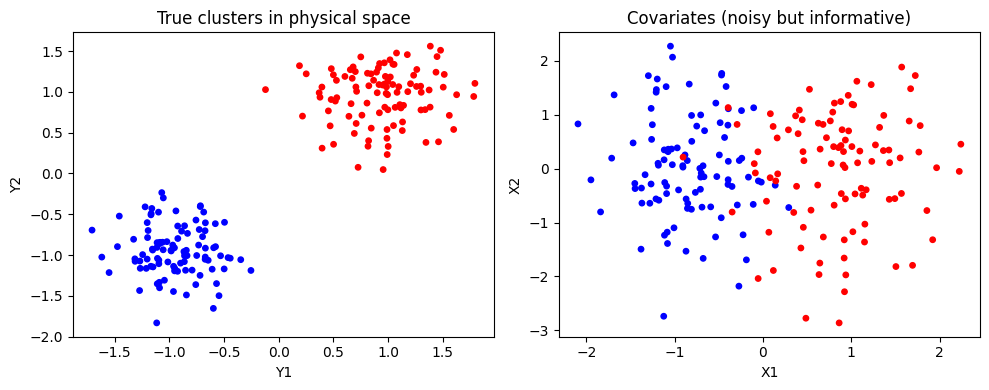

In [ ]:
Y_phys, z_true = simulate_two_clusters_2d()
X_cov = simulate_covariates(z_true)

# Standardize
Y_phys = (Y_phys - Y_phys.mean(axis=0)) / Y_phys.std(axis=0)
X_cov  = (X_cov  - X_cov.mean(axis=0))  / X_cov.std(axis=0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_true, cmap="bwr", s=15)
plt.title("True clusters in physical space")
plt.xlabel("Y1")
plt.ylabel("Y2")

plt.subplot(1,2,2)
plt.scatter(X_cov[:,0], X_cov[:,1], c=z_true, cmap="bwr", s=15)
plt.title("Covariates (noisy but informative)")
plt.xlabel("X1")
plt.ylabel("X2")

plt.tight_layout()
plt.show()



In [ ]:
S_ppm, k_ppm = gibbs_pitmanyor_2d_collapsed(
    Y_phys,
    n_iter=1000,
    alpha=1.0,
    d=0.5,
    seed=42
)


In [ ]:
S_ppmx, k_ppmx = gibbs_ppmx_pitmanyor_2d_collapsed(
    y=Y_phys,
    x=X_cov,
    n_iter=1000,
    alpha=1.0,
    d=0.1,
    eta=1.0,   # turn covariates ON
    seed=42
)


In [ ]:

k_ppm_post  = k_ppm[burn_in:]
k_ppmx_post = k_ppmx[burn_in:]

print("PPM  K frequencies:", dict(zip(*np.unique(k_ppm_post,  return_counts=True))))
print("PPMx K frequencies:", dict(zip(*np.unique(k_ppmx_post, return_counts=True))))
print("PPM  min/max K:", np.min(k_ppm),  np.max(k_ppm))
print("PPMx min/max K:", np.min(k_ppmx), np.max(k_ppmx))


PPM  K frequencies: {np.int64(1): np.int64(277), np.int64(2): np.int64(165), np.int64(3): np.int64(43), np.int64(4): np.int64(14), np.int64(9): np.int64(1)}
PPMx K frequencies: {np.int64(2): np.int64(241), np.int64(3): np.int64(203), np.int64(4): np.int64(45), np.int64(5): np.int64(9), np.int64(6): np.int64(2)}
PPM  min/max K: 1 9
PPMx min/max K: 1 6


In [ ]:
burn_in = 500

z_ppm  = binder_ls(S_ppm,  burn_in)
z_ppmx = binder_ls(S_ppmx, burn_in)


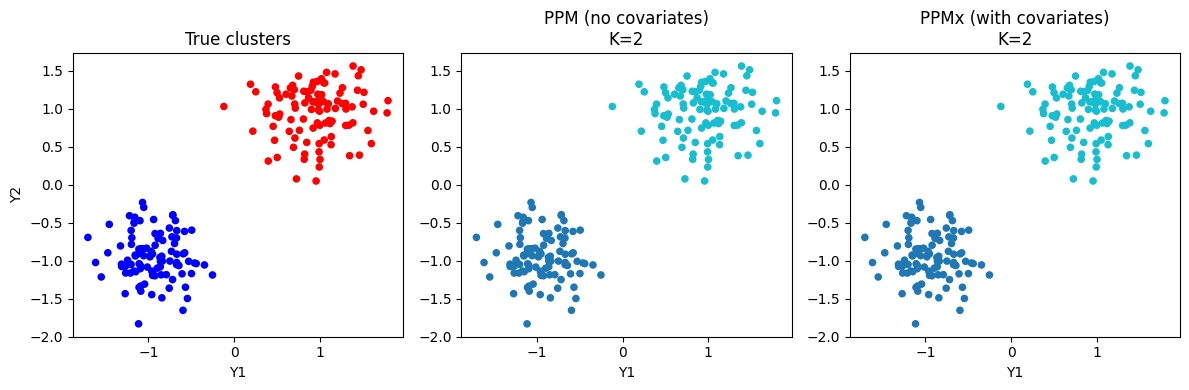

In [ ]:
plt.figure(figsize=(12,4))

# TRUE
plt.subplot(1,3,1)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_true, cmap="bwr", s=20)
plt.title("True clusters")
plt.xlabel("Y1"); plt.ylabel("Y2")

# PPM (no covariates)
plt.subplot(1,3,2)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_ppm, cmap="tab10", s=20)
plt.title(f"PPM (no covariates)\nK={len(np.unique(z_ppm))}")
plt.xlabel("Y1")

# PPMx
plt.subplot(1,3,3)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_ppmx, cmap="tab10", s=20)
plt.title(f"PPMx (with covariates)\nK={len(np.unique(z_ppmx))}")
plt.xlabel("Y1")

plt.tight_layout()
plt.show()


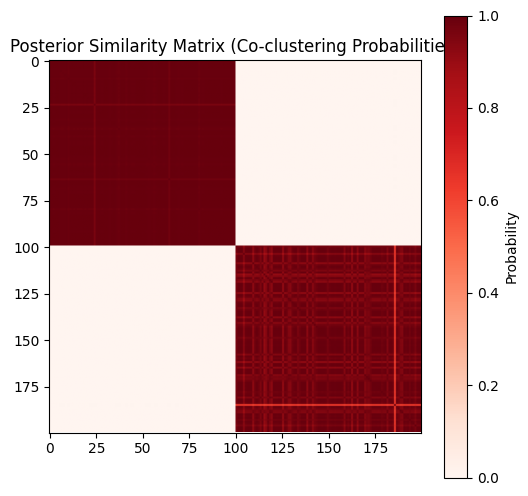

In [ ]:

# Compute the matrix
ps_matrix = posterior_similarity_matrix(S_ppmx, burn_in)

# Plot as a heatmap
plt.figure(figsize=(6, 6))
plt.imshow(ps_matrix, cmap='Reds', origin='upper')
plt.title("Posterior Similarity Matrix (Co-clustering Probabilities)")
plt.colorbar(label="Probability")
plt.show()

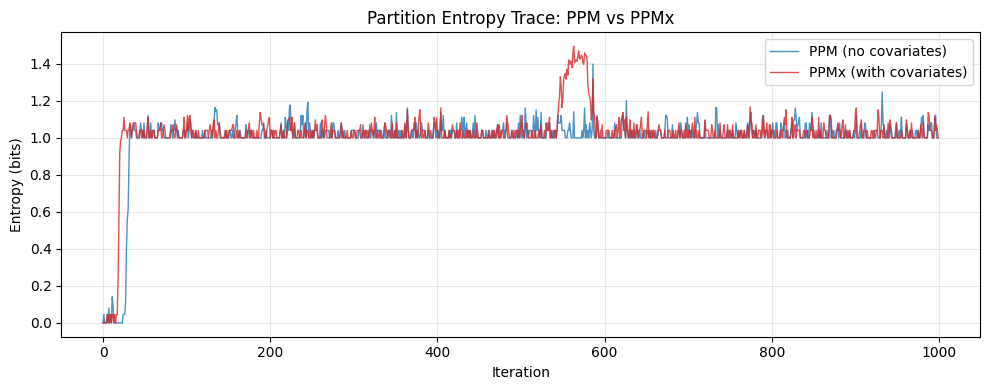

In [ ]:

# Calculate entropy for every sample in the trace
entropy_ppm  = [calculate_entropy(s) for s in S_ppm]
entropy_ppmx = [calculate_entropy(s) for s in S_ppmx]

# Plot the trace
plt.figure(figsize=(10, 4))

plt.plot(entropy_ppm,  lw=1.0, color="tab:blue",  alpha=0.8, label="PPM (no covariates)")
plt.plot(entropy_ppmx, lw=1.0, color="tab:red",   alpha=0.8, label="PPMx (with covariates)")

plt.title("Partition Entropy Trace: PPM vs PPMx")
plt.xlabel("Iteration")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


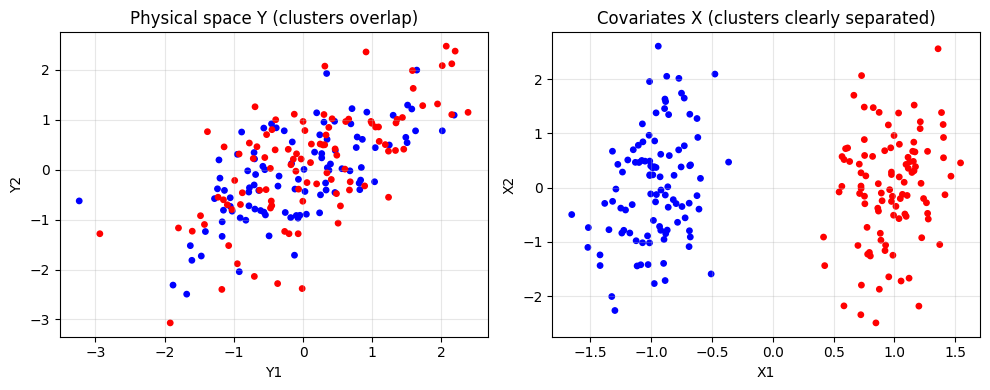

In [ ]:
# Simulate
Y_phys, X_cov, z_true = simulate_overlap_physical_distinct_covariates(n1=100, n2=100, seed=42)

# Standardize both (recommended)
Y_phys = (Y_phys - Y_phys.mean(axis=0)) / Y_phys.std(axis=0)
X_cov  = (X_cov  - X_cov.mean(axis=0))  / X_cov.std(axis=0)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_true, cmap="bwr", s=15)
plt.title("Physical space Y (clusters overlap)")
plt.xlabel("Y1"); plt.ylabel("Y2")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(X_cov[:,0], X_cov[:,1], c=z_true, cmap="bwr", s=15)
plt.title("Covariates X (clusters clearly separated)")
plt.xlabel("X1"); plt.ylabel("X2")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# PPM
S_ppm, k_ppm = gibbs_pitmanyor_2d_collapsed(
    Y_phys,
    n_iter=1000,
    alpha=5.0,
    d=0.0,
    seed=42,
    Lambda0=np.eye(2) * 0.5
)

# PPMx (with covariates)
S_ppmx, k_ppmx = gibbs_ppmx_pitmanyor_2d_collapsed(
    y=Y_phys,
    x=X_cov,
    n_iter=1000,
    alpha=5.0,
    d=0.0,
    eta=1.0,
    seed=42
)

burn_in = 500
z_ppm  = binder_ls(S_ppm, burn_in)
z_ppmx = binder_ls(S_ppmx, burn_in)
# PPM
S_ppm, k_ppm = gibbs_pitmanyor_2d_collapsed(
    Y_phys,
    n_iter=1000,
    alpha=5.0,
    d=0.0,
    seed=42,
    Lambda0=np.eye(2) * 0.5
)

# PPMx
S_ppmx, k_ppmx = gibbs_ppmx_pitmanyor_2d_collapsed(
    y=Y_phys,
    x=X_cov,
    n_iter=1000,
    alpha=5.0,
    d=0.0,
    eta=1.0,
    seed=42
)

burn_in = 500
z_ppm  = binder_ls(S_ppm, burn_in)
z_ppmx = binder_ls(S_ppmx, burn_in)


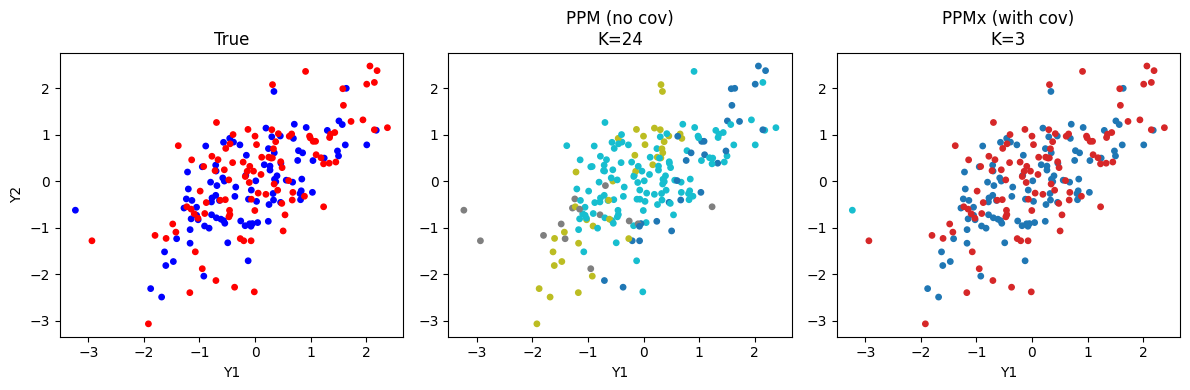

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_true, cmap="bwr", s=15)
plt.title("True")
plt.xlabel("Y1"); plt.ylabel("Y2")

plt.subplot(1,3,2)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_ppm, cmap="tab10", s=15)
plt.title(f"PPM (no cov)\nK={len(np.unique(z_ppm))}")
plt.xlabel("Y1")

plt.subplot(1,3,3)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_ppmx, cmap="tab10", s=15)
plt.title(f"PPMx (with cov)\nK={len(np.unique(z_ppmx))}")
plt.xlabel("Y1")

plt.tight_layout()
plt.show()


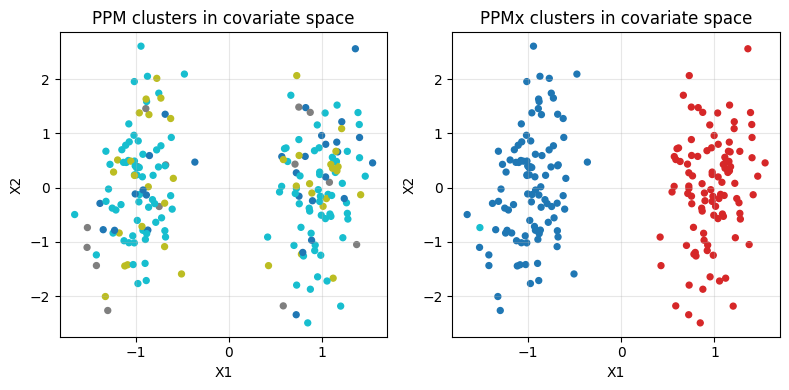

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.scatter(
    X_cov[:, 0], X_cov[:, 1],
    c=z_ppm, cmap="tab10", s=18
)
plt.title("PPM clusters in covariate space")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(
    X_cov[:, 0], X_cov[:, 1],
    c=z_ppmx, cmap="tab10", s=18
)
plt.title("PPMx clusters in covariate space")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


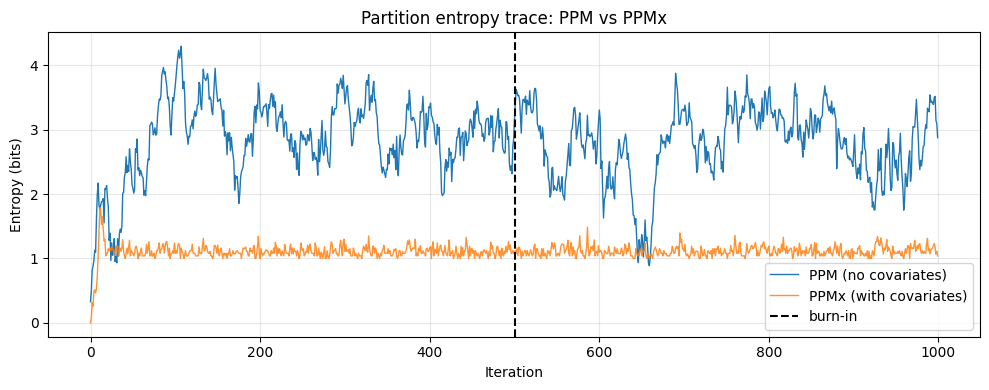

In [ ]:
entropy_ppm  = [calculate_entropy(s) for s in S_ppm]
entropy_ppmx = [calculate_entropy(s) for s in S_ppmx]

plt.figure(figsize=(10,4))
plt.plot(entropy_ppm,  label="PPM (no covariates)", lw=1.0)
plt.plot(entropy_ppmx, label="PPMx (with covariates)", lw=1.0, alpha=0.85)
plt.axvline(burn_in, ls="--", color="black", label="burn-in")
plt.title("Partition entropy trace: PPM vs PPMx")
plt.xlabel("Iteration")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

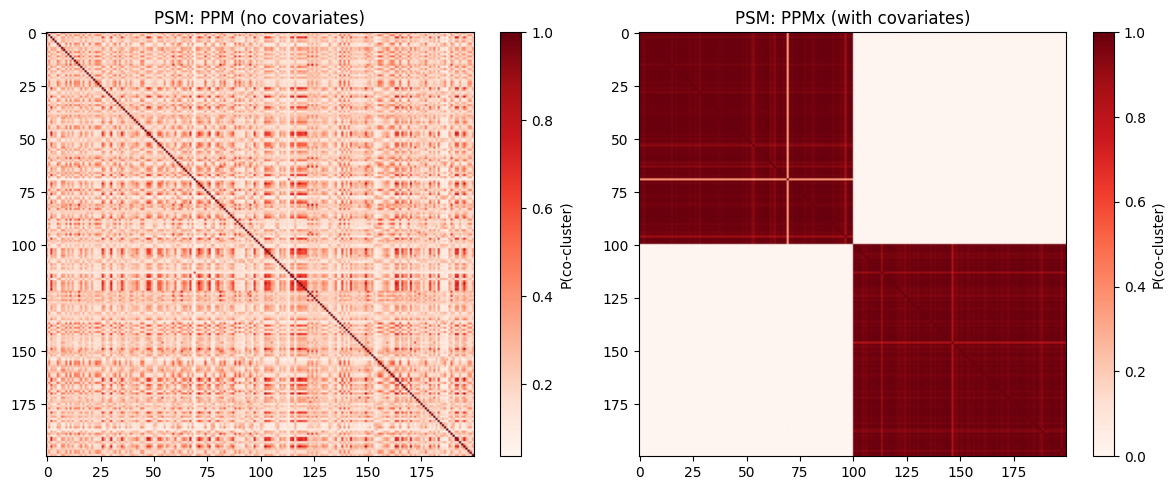

In [ ]:
psm_ppm  = posterior_similarity_matrix(S_ppm,  burn_in)
psm_ppmx = posterior_similarity_matrix(S_ppmx, burn_in)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(psm_ppm, cmap="Reds", origin="upper", aspect="auto")
plt.title("PSM: PPM (no covariates)")
plt.colorbar(label="P(co-cluster)")

plt.subplot(1,2,2)
plt.imshow(psm_ppmx, cmap="Reds", origin="upper", aspect="auto")
plt.title("PSM: PPMx (with covariates)")
plt.colorbar(label="P(co-cluster)")

plt.tight_layout()
plt.show()

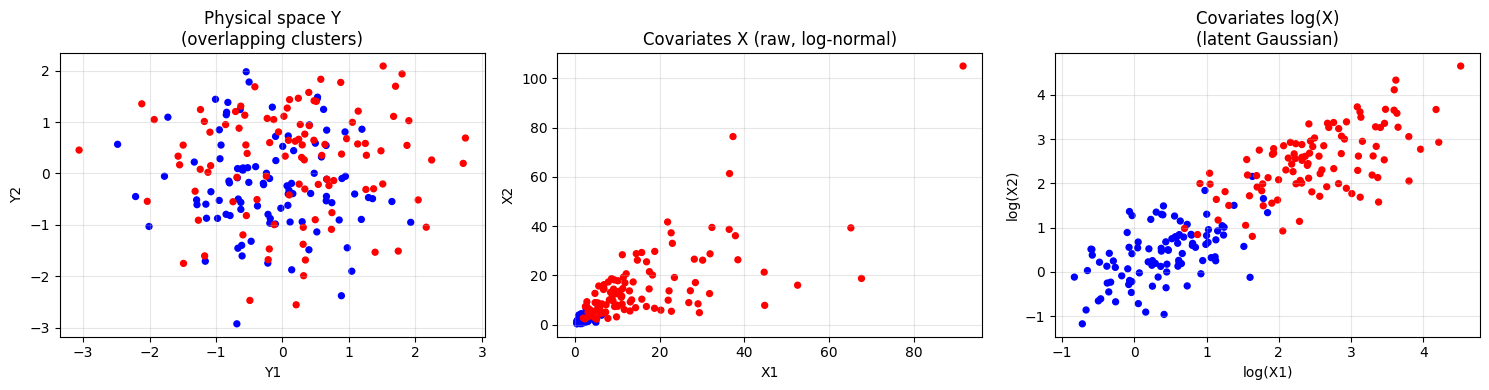

In [ ]:
def simulate_lognormal_clusters_2d(n1=100, n2=100, seed=123):
    rng = np.random.default_rng(seed)

    # Latent normal means
    mu1 = np.array([0.5, 0.5])
    mu2 = np.array([2.5, 2.5])

    Sigma = np.array([[0.5, 0.3],
                      [0.3, 0.5]])

    # Latent normal variables
    z1 = rng.multivariate_normal(mu1, Sigma, size=n1)
    z2 = rng.multivariate_normal(mu2, Sigma, size=n2)

    # Observed covariates (log-normal)
    x1 = np.exp(z1)
    x2 = np.exp(z2)

    X_cov = np.vstack([x1, x2])
    z_true = np.array([0]*n1 + [1]*n2)

    return X_cov, z_true
X_cov_raw, z_true = simulate_lognormal_clusters_2d()
def simulate_physical_space(z_true, seed=123):
    rng = np.random.default_rng(seed)
    n = len(z_true)

    Y = np.zeros((n, 2))
    for i in range(n):
        if z_true[i] == 0:
            Y[i] = rng.normal([0.0, 0.0], [1.0, 1.0])
        else:
            Y[i] = rng.normal([0.5, 0.5], [1.0, 1.0])  # overlapping
    return Y

Y_phys = simulate_physical_space(z_true)
Y_phys = (Y_phys - Y_phys.mean(axis=0)) / Y_phys.std(axis=0)
plt.figure(figsize=(15, 4))

# --- Physical space ---
plt.subplot(1, 3, 1)
plt.scatter(
    Y_phys[:, 0], Y_phys[:, 1],
    c=z_true, cmap="bwr", s=18
)
plt.title("Physical space Y\n(overlapping clusters)")
plt.xlabel("Y1")
plt.ylabel("Y2")
plt.grid(alpha=0.3)

# --- covariates (log-normal) ---
plt.subplot(1, 3, 2)
plt.scatter(
    X_cov_raw[:, 0], X_cov_raw[:, 1],
    c=z_true, cmap="bwr", s=18
)
plt.title("Covariates X (raw, log-normal)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(alpha=0.3)

# --- Log-transformed covariates ---
plt.subplot(1, 3, 3)
plt.scatter(
    np.log(X_cov_raw[:, 0]),
    np.log(X_cov_raw[:, 1]),
    c=z_true, cmap="bwr", s=18
)
plt.title("Covariates log(X)\n(latent Gaussian)")
plt.xlabel("log(X1)")
plt.ylabel("log(X2)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# - covariates: log + standardize (valid because log-normal => positive)
X_cov = np.log(X_cov_raw)
X_cov = (X_cov - X_cov.mean(axis=0)) / X_cov.std(axis=0)

In [ ]:
# ============================================================
# 1) Run PPM : collapsed DP/PY on Y only
# ============================================================
S_ppm, k_ppm = gibbs_pitmanyor_2d_collapsed(
    Y_phys,
    n_iter=1000,
    alpha=5.0,
    d=0.0,                 # DP baseline while debugging
    seed=42,
    Lambda0=np.eye(2)*0.5  # tighter prior helps avoid "one fat cluster"
)


In [ ]:
# ============================================================
# 2) Run PPMx (with covariates): collapsed DP/PY on Y + PPMx prior on X
# ============================================================
S_ppmx, k_ppmx = gibbs_ppmx_pitmanyor_2d_collapsed(
    y=Y_phys,
    x=X_cov,
    n_iter=1000,
    alpha=5.0,
    d=0.0,
    eta=1.0,               # increase if you want covariates to matter more
    seed=42
)

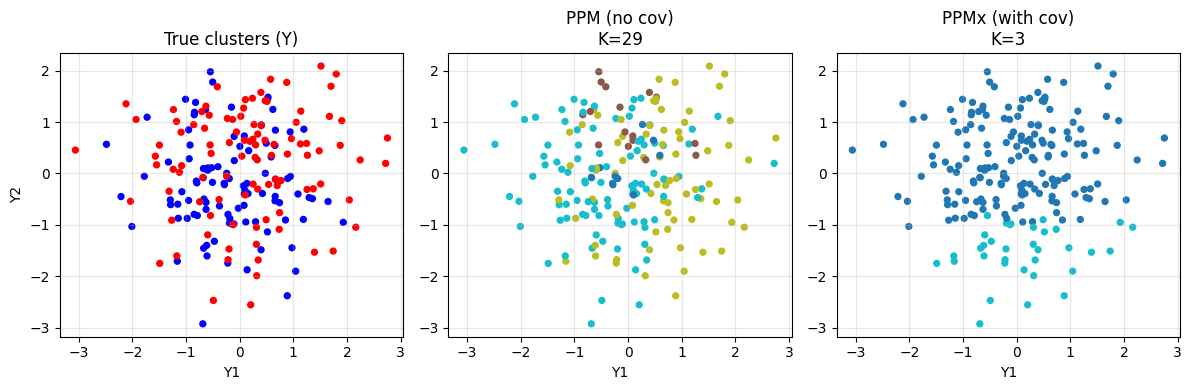

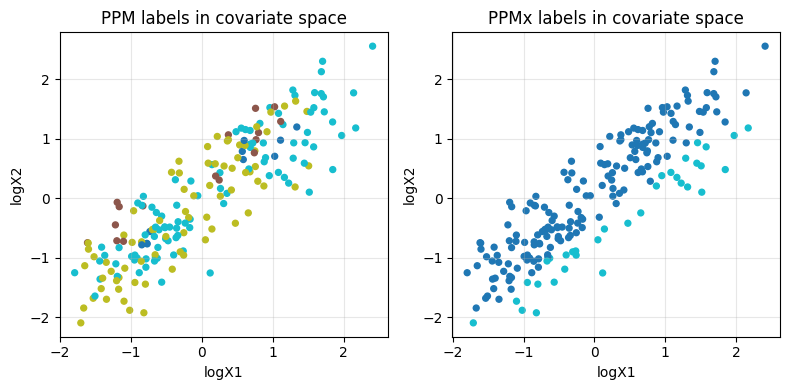

In [ ]:
# ============================================================
# 3) Point estimates (Binder/Dahl LS) + plots
# ============================================================
burn_in = 500
z_ppm  = binder_ls(S_ppm,  burn_in)
z_ppmx = binder_ls(S_ppmx, burn_in)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_true, cmap="bwr", s=18)
plt.title("True clusters (Y)")
plt.xlabel("Y1"); plt.ylabel("Y2"); plt.grid(alpha=0.3)

plt.subplot(1,3,2)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_ppm, cmap="tab10", s=18)
plt.title(f"PPM (no cov)\nK={len(np.unique(z_ppm))}")
plt.xlabel("Y1"); plt.grid(alpha=0.3)

plt.subplot(1,3,3)
plt.scatter(Y_phys[:,0], Y_phys[:,1], c=z_ppmx, cmap="tab10", s=18)
plt.title(f"PPMx (with cov)\nK={len(np.unique(z_ppmx))}")
plt.xlabel("Y1"); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Also plot in covariate space to show why PPMx works
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.scatter(X_cov[:,0], X_cov[:,1], c=z_ppm, cmap="tab10", s=18)
plt.title("PPM labels in covariate space")
plt.xlabel("logX1"); plt.ylabel("logX2"); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(X_cov[:,0], X_cov[:,1], c=z_ppmx, cmap="tab10", s=18)
plt.title("PPMx labels in covariate space")
plt.xlabel("logX1"); plt.ylabel("logX2"); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



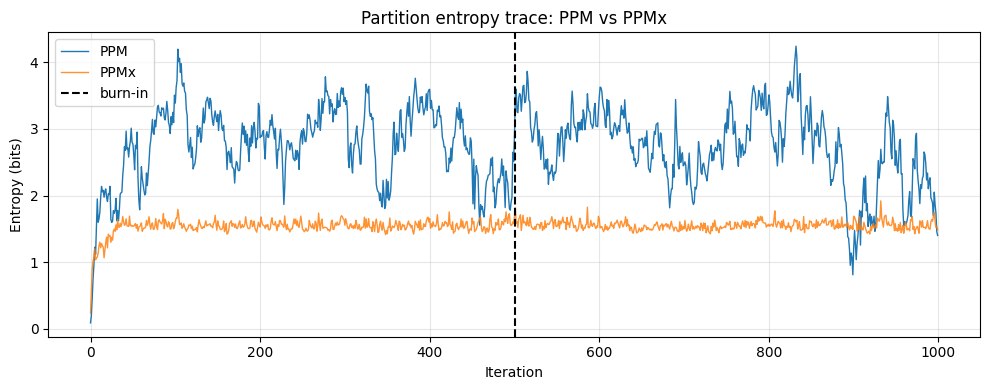

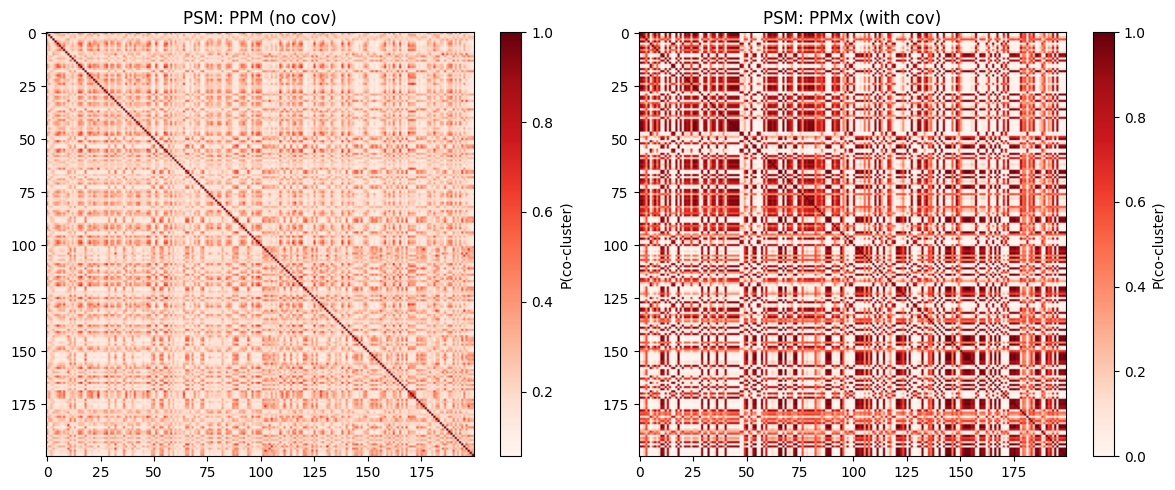

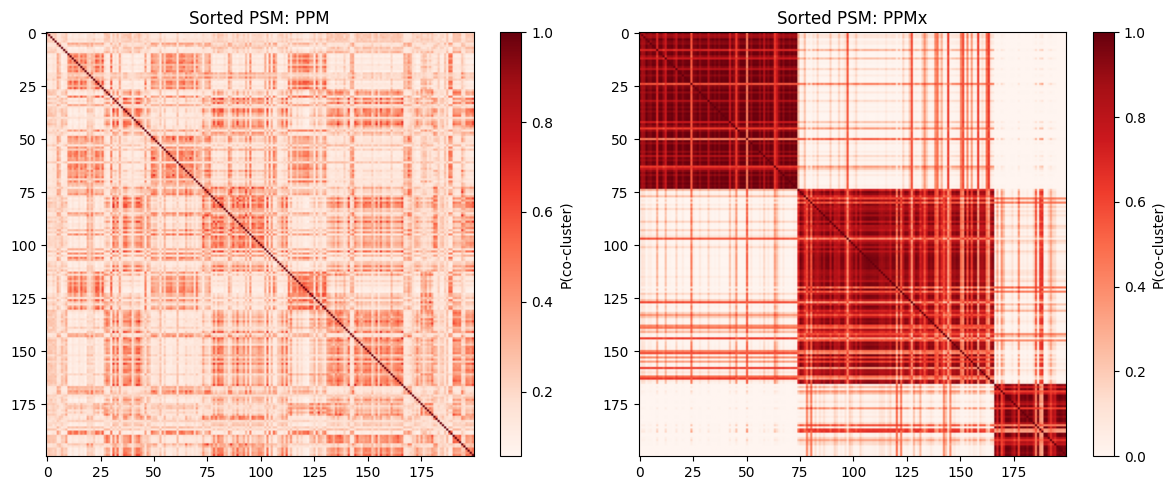

In [ ]:

# ============================================================
# 4) Entropy traces (PPM vs PPMx)
# ============================================================
entropy_ppm  = [calculate_entropy(s) for s in S_ppm]
entropy_ppmx = [calculate_entropy(s) for s in S_ppmx]

plt.figure(figsize=(10,4))
plt.plot(entropy_ppm,  label="PPM",  lw=1.0)
plt.plot(entropy_ppmx, label="PPMx", lw=1.0, alpha=0.85)
plt.axvline(burn_in, ls="--", color="black", label="burn-in")
plt.title("Partition entropy trace: PPM vs PPMx")
plt.xlabel("Iteration")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 5) Posterior similarity matrices (PSM) for both + sorted versions
# ============================================================

psm_ppm  = posterior_similarity_matrix(S_ppm,  burn_in)
psm_ppmx = posterior_similarity_matrix(S_ppmx, burn_in)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(psm_ppm, cmap="Reds", origin="upper", aspect="auto")
plt.title("PSM: PPM (no cov)")
plt.colorbar(label="P(co-cluster)")

plt.subplot(1,2,2)
plt.imshow(psm_ppmx, cmap="Reds", origin="upper", aspect="auto")
plt.title("PSM: PPMx (with cov)")
plt.colorbar(label="P(co-cluster)")

plt.tight_layout()
plt.show()

# Sorted PSMs reveal blocks (sort by point estimate labels)
order_ppm  = np.argsort(z_ppm)
order_ppmx = np.argsort(z_ppmx)

psm_ppm_sorted  = psm_ppm[order_ppm][:, order_ppm]
psm_ppmx_sorted = psm_ppmx[order_ppmx][:, order_ppmx]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(psm_ppm_sorted, cmap="Reds", origin="upper", aspect="auto")
plt.title("Sorted PSM: PPM")
plt.colorbar(label="P(co-cluster)")

plt.subplot(1,2,2)
plt.imshow(psm_ppmx_sorted, cmap="Reds", origin="upper", aspect="auto")
plt.title("Sorted PSM: PPMx")
plt.colorbar(label="P(co-cluster)")

plt.tight_layout()
plt.show()

In [ ]:
#original dataset

In [ ]:
# Load the original large dataset
print("Loading original dataset...")
#enter the dataset for our own project
dataset = pd.read_hdf(r"D:\Downloads\dataset.h5", key='dataset')
print(f"Original dataset shape: {dataset.shape}")

#subsample
sample_size = 3000
dataset_sample = dataset.sample(n=sample_size, random_state=42)

print(f"Subsampled dataset shape: {dataset_sample.shape}")
print("\nFirst 5 rows of the subsample:")
print(dataset_sample.head())

Loading original dataset...
Original dataset shape: (32713638, 4)
Subsampled dataset shape: (3000, 4)

First 5 rows of the subsample:
              Cov1          Cov2  EclipticLatitude  EclipticLongitude
26354832  0.000181  2.124372e-21         -0.155192          -1.630462
8161725   0.000178  8.925264e-22         -0.087593          -1.691873
14332150  0.000293  1.017267e-20         -0.692274          -2.003358
25375656  0.000218  3.032489e-21         -0.056902          -1.584419
28539229  0.000097  1.064142e-22         -0.171033          -1.738772


In [ ]:
def preprocess_dataset_sample(df, eps=1e-300):
    """
    Returns:
      Y_phys : (N,2) standardized physical variables
      X_cov  : (N,2) standardized log-covariates
      df_proc: dataframe with extra columns
    """
    df_proc = df.copy()

    # --- safe log for covariates ---
    df_proc["Cov1_safe"] = np.maximum(df_proc["Cov1"].astype(float).values, eps)
    df_proc["Cov2_safe"] = np.maximum(df_proc["Cov2"].astype(float).values, eps)

    df_proc["log_Cov1"] = np.log(df_proc["Cov1_safe"])
    df_proc["log_Cov2"] = np.log(df_proc["Cov2_safe"])

    # --- physical variables ---
    Y_phys = df_proc[["EclipticLatitude", "EclipticLongitude"]].values
    Y_phys = (Y_phys - Y_phys.mean(axis=0)) / Y_phys.std(axis=0)

    # --- covariates ---
    X_cov = df_proc[["log_Cov1", "log_Cov2"]].values
    X_cov = (X_cov - X_cov.mean(axis=0)) / X_cov.std(axis=0)

    return Y_phys, X_cov, df_proc


In [ ]:
Y_phys, X_cov, df_proc = preprocess_dataset_sample(dataset_sample)


In [ ]:
S_ppm, k_ppm = gibbs_pitmanyor_2d_collapsed(
    Y_phys,
    n_iter=500,
    alpha=1.0,
    d=0.0,
    seed=42
)

burn_in = S_ppm.shape[0] // 2
z_ppm = binder_ls(S_ppm, burn_in)


In [ ]:
S_ppmx, k_ppmx = gibbs_ppmx_pitmanyor_2d_collapsed(
    y=Y_phys,
    x=X_cov,
    n_iter=500,
    alpha=1.0,
    d=0.0,
    eta=0.5,
    seed=42
)

z_ppmx = binder_ls(S_ppmx, burn_in)


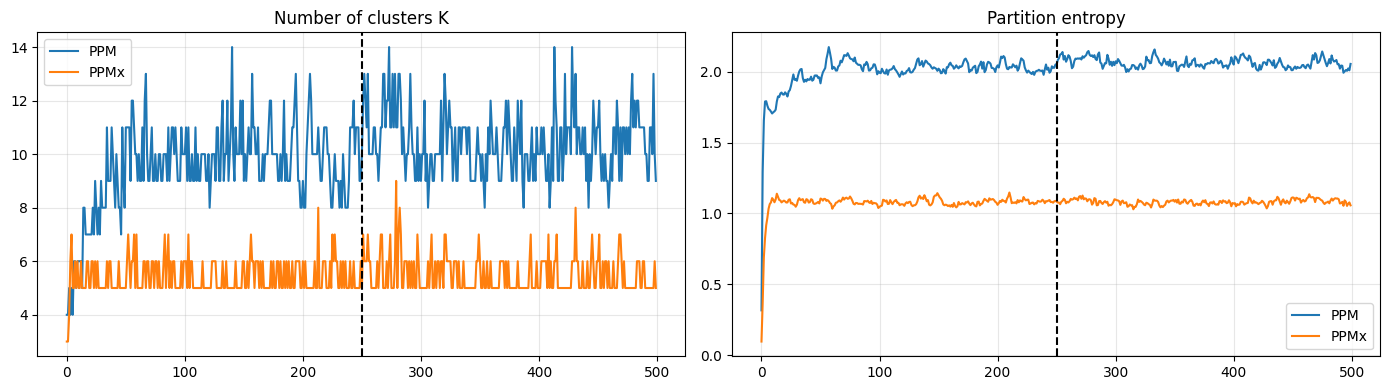

In [ ]:
entropy_ppm  = [calculate_entropy(s) for s in S_ppm]
entropy_ppmx = [calculate_entropy(s) for s in S_ppmx]

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(k_ppm, label="PPM")
plt.plot(k_ppmx, label="PPMx")
plt.axvline(burn_in, ls="--", c="k")
plt.title("Number of clusters K")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(entropy_ppm,  label="PPM")
plt.plot(entropy_ppmx, label="PPMx")
plt.axvline(burn_in, ls="--", c="k")
plt.title("Partition entropy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


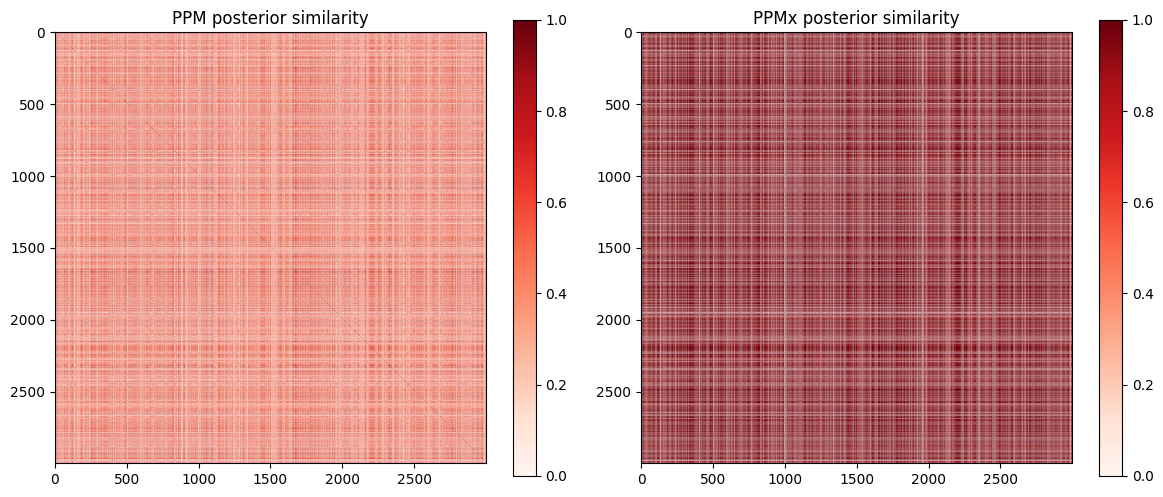

In [ ]:
P_ppm  = posterior_similarity_matrix(S_ppm,  burn_in)
P_ppmx = posterior_similarity_matrix(S_ppmx, burn_in)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(P_ppm, cmap="Reds")
plt.title("PPM posterior similarity")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(P_ppmx, cmap="Reds")
plt.title("PPMx posterior similarity")
plt.colorbar()

plt.tight_layout()
plt.show()


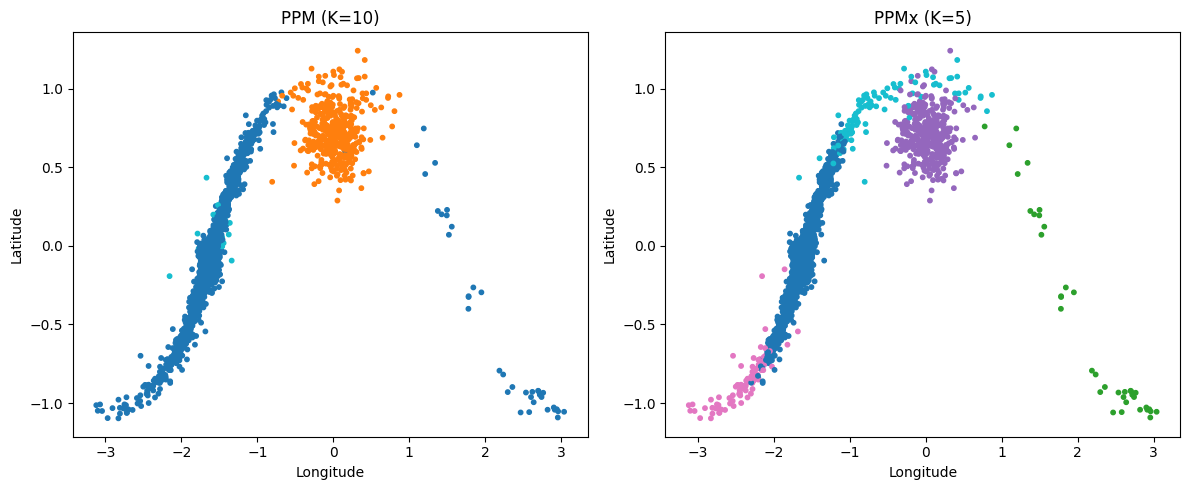

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(
    df_proc["EclipticLongitude"],
    df_proc["EclipticLatitude"],
    c=z_ppm, s=10, cmap="tab10"
)
plt.title(f"PPM (K={len(np.unique(z_ppm))})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.subplot(1,2,2)
plt.scatter(
    df_proc["EclipticLongitude"],
    df_proc["EclipticLatitude"],
    c=z_ppmx, s=10, cmap="tab10"
)
plt.title(f"PPMx (K={len(np.unique(z_ppmx))})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


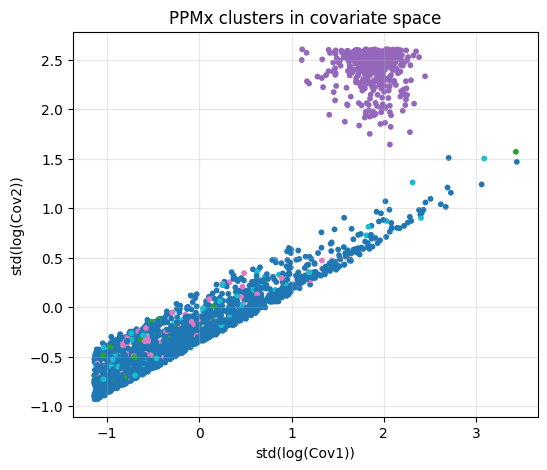

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_cov[:,0], X_cov[:,1], c=z_ppmx, s=10, cmap="tab10")
plt.xlabel("std(log(Cov1))")
plt.ylabel("std(log(Cov2))")
plt.title("PPMx clusters in covariate space")
plt.grid(alpha=0.3)
plt.show()
